In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/MyDrive/NLP/Translation')
!ls

'arabic dataset'     'french dataset'	 sentiment_gpt3_train.jsonl
'chinese dataset'     get-pip.py	'Translation v1.ipynb'
 Datasets.ipynb       get-pip.py.1	'Translation v2.ipynb'
'Datasets v2.ipynb'  'italian dataset'
 final_models	      merged_datasets


# **GoogleTranslate + DeBERTa**

In [ ]:
!pip -q install -U transformers datasets evaluate accelerate

import torch
print("✅ PyTorch sürümü:", torch.__version__)
print("🔌 CUDA kullanılabilir mi:", torch.cuda.is_available())

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    cc = torch.cuda.get_device_capability(0)
    print(f"💻 GPU: {gpu_name} (Compute Capability: {cc})")
    USE_BF16 = (cc[0] >= 8)
else:
    USE_BF16 = False

print("⚙️ bf16 kullanılacak mı?", USE_BF16)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.3/506.3 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 63.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 21.0.0 which is incompatible.
pylibcudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 21.0.0 which is incompatible.
✅ PyTorch sürümü: 2.8.0+cu126
🔌 CUDA kullanılabilir mi: True
💻 GPU: NVIDIA L4 (Compute Capability: (8, 9))
⚙️ bf16 kullanılacak mı? True


In [ ]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/NLP/Translation/merged_datasets/merged_balanced_translated_google_clean.csv"

df = pd.read_csv(DATA_PATH)
print("✅ Veri seti yüklendi:", df.shape)
print("📂 Sütunlar:", df.columns.tolist())

print("\n🔍 Örnek kayıtlar:")
display(df.head(3))

missing = df["translated_text"].isna().sum()
empty = (df["translated_text"].astype(str).str.strip() == "").sum()
print(f"\n❌ Eksik çeviri sayısı: {missing} | ⚠️ Boş string sayısı: {empty}")

print("\n🎯 Sınıf dağılımı:")
print(df["sentiment"].value_counts())

✅ Veri seti yüklendi: (11997, 4)
📂 Sütunlar: ['text', 'sentiment', 'language', 'translated_text']

🔍 Örnek kayıtlar:


,text,sentiment,language,translated_text
0,بطلنا نحكم على الناس من شكلهم و لبسهم و تمن خر...,NEG,ar,"We stopped judging people by their looks, thei..."
1,vérifier la quantité à la livraison jai acheté...,NEG,fr,check the quantity on delivery I bought these ...
2,برومو حلقة بائع الليمون ثاني حلقات الأنيميشن م...,NEG,ar,"Promo for the Lemon Seller episode, the second..."



❌ Eksik çeviri sayısı: 0 | ⚠️ Boş string sayısı: 0

🎯 Sınıf dağılımı:
sentiment
NEG        4864
POS        3838
NEUTRAL    3295
Name: count, dtype: int64


In [ ]:
df = df[["translated_text", "sentiment", "language"]].copy()

label_map = {"NEG": 0, "NEUTRAL": 1, "POS": 2}
df["label"] = df["sentiment"].map(label_map).astype(int)

print("✅ Dönüştürülmüş tablo boyutu:", df.shape)
print("\n🎯 Etiket örnekleri:")
print(df["label"].value_counts())

display(df.sample(3, random_state=42))

✅ Dönüştürülmüş tablo boyutu: (11997, 4)

🎯 Etiket örnekleri:
label
0    4864
2    3838
1    3295
Name: count, dtype: int64


,translated_text,sentiment,language,label
1934,defective furniture hello I received the TV ca...,NEG,fr,0
4035,Storming the embassy is not peaceful,NEG,ar,0
11862,The quality is pretty good. I liked this bag t...,POS,zh,2


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from transformers import AutoTokenizer

SEED = 42
np.random.seed(SEED)

def macro_specificity(y_true, y_pred, num_labels=3):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_labels)))
    specs = []
    total = cm.sum()
    for i in range(num_labels):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = total - TP - FP - FN
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        specs.append(spec)
    return float(np.mean(specs))

def compute_metrics_fn(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "precision_w": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall_w": recall_score(labels, preds, average="weighted", zero_division=0),
        "specificity_macro": macro_specificity(labels, preds, num_labels=3),
    }

MODEL_NAME = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN = 128

print("✅ Tokenizer yüklendi:", MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


✅ Tokenizer yüklendi: microsoft/deberta-v3-base


In [ ]:
from sklearn.model_selection import StratifiedKFold
from datasets import Dataset

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def tokenize_batch(batch):
    return tokenizer(
        batch["translated_text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )

print("✅ 5-Fold yapısı ve tokenize fonksiyonu hazır.")

✅ 5-Fold yapısı ve tokenize fonksiyonu hazır.


In [ ]:
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
import torch, gc, os

fold_results = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(df["translated_text"], df["label"]), start=1):
    print(f"\n📘 Fold {fold} başlıyor...")


    train_df = df.iloc[tr_idx][["translated_text", "label"]]
    val_df   = df.iloc[va_idx][["translated_text", "label"]]


    train_ds = Dataset.from_pandas(train_df).map(tokenize_batch, batched=True, remove_columns=["translated_text"])
    val_ds   = Dataset.from_pandas(val_df).map(tokenize_batch, batched=True, remove_columns=["translated_text"])

    train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
    val_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])


    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)


    args = TrainingArguments(
        output_dir=f"/content/deberta_kfold/fold_{fold}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=3e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        num_train_epochs=5,
        weight_decay=0.05,
        warmup_ratio=0.1,
        logging_strategy="epoch",
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1_weighted",
        greater_is_better=True,
        gradient_checkpointing=False,
        gradient_accumulation_steps=2,
        fp16=(not USE_BF16),
        bf16=USE_BF16,
        dataloader_pin_memory=True,
        dataloader_num_workers=2,
        save_total_limit=1,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics_fn,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
    )

    trainer.train()

    metrics = trainer.evaluate()
    print(f"📊 Fold {fold} sonuçları:", metrics)
    fold_results.append(metrics)

    del model, trainer, train_ds, val_ds
    gc.collect()
    torch.cuda.empty_cache()

print("\n✅ Tüm Fold'lar tamamlandı.")


📘 Fold 1 başlıyor...


Map:   0%|          | 0/9597 [00:00<?, ? examples/s]

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3944706179.py:53: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro,Precision W,Recall W,Specificity Macro
1,0.833900,0.727327,0.685417,0.691147,0.680519,0.701812,0.685417,0.845266
2,0.618000,0.712960,0.705417,0.696260,0.679175,0.693882,0.705417,0.849994
3,0.441700,0.807749,0.703750,0.704640,0.692615,0.705618,0.703750,0.851771
4,0.289300,1.097595,0.696667,0.695422,0.682454,0.696052,0.696667,0.849185


...

Map:   0%|          | 0/9598 [00:00<?, ? examples/s]

Map:   0%|          | 0/2399 [00:00<?, ? examples/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3944706179.py:53: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro,Precision W,Recall W,Specificity Macro
1,0.839200,0.762349,0.684869,0.672171,0.653732,0.674475,0.684869,0.841634
2,0.631300,0.716893,0.709045,0.701030,0.685166,0.699692,0.709045,0.851490
3,0.462500,0.857921,0.702376,0.703930,0.691317,0.705855,0.702376,0.852024
4,0.305000,1.011748,0.704877,0.705989,0.693305,0.707467,0.704877,0.853310
5,0.207700,1.225247,0.699041,0.700701,0.688417,0.703543,0.699041,0.850904


📊 Fold 5 sonuçları: {'eval_loss': 1.0117475986480713, 'eval_accuracy': 0.7048770320967069, 'eval_f1_weighted': 0.7059889538778881, 'eval_f1_macro': 0.6933050403429917, 'eval_precision_w': 0.7074668428791083, 'eval_recall_w': 0.7048770320967069, 'eval_specificity_macro': 0.8533104894162787, 'eval_runtime': 4.6466, 'eval_samples_per_second': 516.297, 'eval_steps_per_second': 32.282, 'epoch': 5.0}

✅ Tüm Fold'lar tamamlandı.


In [ ]:
import shutil, os

# Eğittiğin model klasörlerinin listesi
trained_models = [
    "/content/deberta_kfold",
]

# Kaydedilecek Drive konumu
save_root = "/content/drive/MyDrive/NLP/Translation/final_models"
os.makedirs(save_root, exist_ok=True)

for model_dir in trained_models:
    model_name = os.path.basename(model_dir)
    final_path = os.path.join(save_root, model_name.replace("_kfold", "_final"))

    best_ckpt = None
    best_step = 0

    for root, dirs, files in os.walk(model_dir):
        for d in dirs:
            if d.startswith("checkpoint-"):
                step = int(d.split("-")[1])
                if step > best_step:
                    best_step = step
                    best_ckpt = os.path.join(root, d)

    if best_ckpt:
        print(f"📦 {model_name} -> {best_ckpt} (step {best_step})")
        shutil.copytree(best_ckpt, final_path)
        print(f"✅ {model_name.replace('_kfold','_final')} kaydedildi: {final_path}\n")
    else:
        print(f"⚠️ {model_name} için checkpoint bulunamadı.\n")

print("🏁 Tüm modeller kaydedildi.")


📦 deberta_kfold -> /content/deberta_kfold/fold_4/checkpoint-3000 (step 3000)
✅ deberta_final kaydedildi: /content/drive/MyDrive/NLP/Translation/final_models/deberta_final

🏁 Tüm modeller kaydedildi.


In [ ]:
import pandas as pd
pd.DataFrame(fold_results).mean()

,0
eval_loss,0.968499
eval_accuracy,0.701667
eval_f1_weighted,0.704377
eval_f1_macro,0.692349
eval_precision_w,0.708357
eval_recall_w,0.701667
eval_specificity_macro,0.852301
eval_runtime,11.549300
eval_samples_per_second,207.805000
eval_steps_per_second,25.976000


# **GoogleTranslate Ensemble**

In [54]:
model_paths_libre = {
    "deberta": "/content/drive/MyDrive/NLP/Translation/final_models/deberta_final",
    "roberta": "/content/drive/MyDrive/NLP/Translation/final_models/roberta_final",
    "bertweet": "/content/drive/MyDrive/NLP/Translation/final_models/bertweet_final",
}

In [55]:
import pandas as pd

data_path = "/content/drive/MyDrive/NLP/Translation/merged_datasets/merged_balanced_translated_google_clean.csv"

df = pd.read_csv(data_path)
df.dropna(subset=["translated_text", "sentiment"], inplace=True)
df["translated_text"] = df["translated_text"].astype(str)

label_map = {"NEG": 0, "NEUTRAL": 1, "POS": 2}
df["label"] = df["sentiment"].map(label_map)

print(f"✅ Veri seti yüklendi: {df.shape}")
print(df.head(3))

✅ Veri seti yüklendi: (11997, 5)
                                                text sentiment language  \
0  بطلنا نحكم على الناس من شكلهم و لبسهم و تمن خر...       NEG       ar   
1  vérifier la quantité à la livraison jai acheté...       NEG       fr   
2  برومو حلقة بائع الليمون ثاني حلقات الأنيميشن م...       NEG       ar   

                                     translated_text  label  
0  We stopped judging people by their looks, thei...      0  
1  check the quantity on delivery I bought these ...      0  
2  Promo for the Lemon Seller episode, the second...      0  


In [56]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print(f"✅ Train set: {train_df.shape}")
print(f"✅ Test set:  {test_df.shape}")

print("\n🎯 Test sınıf dağılımı:")
print(test_df["label"].value_counts())

✅ Train set: (9597, 5)
✅ Test set:  (2400, 5)

🎯 Test sınıf dağılımı:
label
0    973
2    768
1    659
Name: count, dtype: int64


In [57]:
common_texts = set(train_df["translated_text"]).intersection(set(test_df["translated_text"]))
print(f"\n⚠️ Ortak örnek sayısı: {len(common_texts)}")

train_df = train_df[~train_df["translated_text"].isin(common_texts)].reset_index(drop=True)
test_df  = test_df[~test_df["translated_text"].isin(common_texts)].reset_index(drop=True)

print(f"✅ Temiz Train set: {train_df.shape}")
print(f"✅ Temiz Test set:  {test_df.shape}")


⚠️ Ortak örnek sayısı: 13
✅ Temiz Train set: (9566, 5)
✅ Temiz Test set:  (2386, 5)


In [22]:
import os, gc, torch, numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
from collections import Counter

device = "cuda" if torch.cuda.is_available() else "cpu"

def predict_labels(texts, model_path, batch_size=16, max_length=128):
    local_path = os.path.normpath(model_path)
    if not os.path.isdir(local_path):
        raise ValueError(f"❌ Model klasörü bulunamadı: {local_path}")

    print(f"📂 Model yükleniyor: {local_path}")
    tokenizer = AutoTokenizer.from_pretrained(
        local_path,
        local_files_only=True,
        trust_remote_code=True
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        local_path,
        local_files_only=True,
        trust_remote_code=True
    ).to(device).eval()

    preds = []
    for i in tqdm(range(0, len(texts), batch_size), desc=os.path.basename(local_path)):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            batch_preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        preds.extend(batch_preds)
        del inputs, outputs
        torch.cuda.empty_cache()

    del model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    return np.array(preds)


def majority_voting_ensemble(texts, model_paths):
    all_preds = []
    for name, path in model_paths.items():
        print(f"\n🔹 Model tahmini alınıyor: {name}")
        preds = predict_labels(texts, path)
        all_preds.append(preds)
    all_preds = np.stack(all_preds, axis=1)
    final_preds = [Counter(row).most_common(1)[0][0] for row in all_preds]
    return np.array(final_preds)


🔹 Model tahmini alınıyor: deberta
📂 Model yükleniyor: /content/drive/MyDrive/NLP/Translation/final_models/deberta_final


deberta_final: 100%|██████████| 150/150 [00:07<00:00, 19.20it/s]



🔹 Model tahmini alınıyor: roberta
📂 Model yükleniyor: /content/drive/MyDrive/NLP/Translation/final_models/roberta_final


roberta_final: 100%|██████████| 150/150 [00:05<00:00, 27.53it/s]
emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0



🔹 Model tahmini alınıyor: bertweet
📂 Model yükleniyor: /content/drive/MyDrive/NLP/Translation/final_models/bertweet_final


bertweet_final: 100%|██████████| 150/150 [00:05<00:00, 25.15it/s]



📊 Majority Voting Ensemble (Google Modelleri):
Accuracy:     0.9007
Precision:    0.9000
Recall:       0.9007
F1-score:     0.8998
Specificity:  0.9496


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


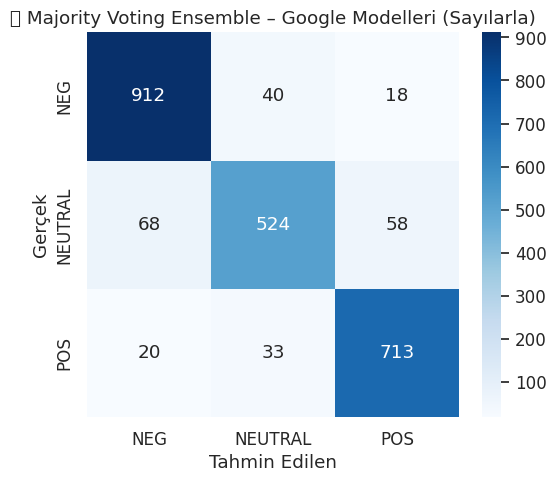


📦 Ham Confusion Matrix:
         NEG  NEUTRAL  POS
NEG      912       40   18
NEUTRAL   68      524   58
POS       20       33  713


In [24]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

texts = test_df["translated_text"].tolist()
labels = test_df["label"].tolist()

preds = majority_voting_ensemble(texts, model_paths_libre)

acc = accuracy_score(labels, preds)
f1 = f1_score(labels, preds, average="weighted")
prec = precision_score(labels, preds, average="weighted")
rec = recall_score(labels, preds, average="weighted")

cm = confusion_matrix(labels, preds)
label_names = ["NEG", "NEUTRAL", "POS"]

specs = []
total = cm.sum()
for i in range(3):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = total - TP - FP - FN
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0
    specs.append(spec)
specificity = np.mean(specs)

print(f"\n📊 Majority Voting Ensemble (Google Modelleri):")
print(f"Accuracy:     {acc:.4f}")
print(f"Precision:    {prec:.4f}")
print(f"Recall:       {rec:.4f}")
print(f"F1-score:     {f1:.4f}")
print(f"Specificity:  {specificity:.4f}")

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.title("📊 Majority Voting Ensemble – Google Modelleri (Sayılarla)")
plt.show()


print("\n📦 Ham Confusion Matrix:")
print(pd.DataFrame(cm, index=label_names, columns=label_names))

# **LibreTranslate + DeBERTa**

In [ ]:
import pandas as pd
from datasets import Dataset
from sklearn.model_selection import StratifiedKFold
import numpy as np, evaluate

data_path = "/content/drive/MyDrive/NLP/Translation/merged_datasets/merged_balanced_translated_libre_fixed.csv"

df = pd.read_csv(data_path)
df.dropna(subset=["translated_text", "sentiment"], inplace=True)
df["translated_text"] = df["translated_text"].astype(str)

label_map = {"NEG": 0, "NEUTRAL": 1, "POS": 2}
df["label"] = df["sentiment"].map(label_map)

print(f"✅ Libre veri seti hazır: {df.shape}")

✅ Libre veri seti hazır: (12000, 5)


In [ ]:
from transformers import AutoTokenizer

model_name = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def tokenize(batch):
    return tokenizer(batch["translated_text"], truncation=True, padding="max_length", max_length=128)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy.compute(predictions=preds, references=labels)["accuracy"]
    f1_score = f1.compute(predictions=preds, references=labels, average="weighted")["f1"]
    return {"accuracy": acc, "f1_weighted": f1_score}

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

In [ ]:
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
import torch, gc, os
from datasets import Dataset
from sklearn.model_selection import StratifiedKFold
import numpy as np

MODEL_NAME = "microsoft/deberta-v3-base"
USE_BF16 = torch.cuda.get_device_capability(0)[0] >= 8

fold_results = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(df["translated_text"], df["label"]), start=1):
    print(f"\n📘 Fold {fold} başlıyor...")

    train_df = df.iloc[tr_idx][["translated_text", "label"]]
    val_df   = df.iloc[va_idx][["translated_text", "label"]]

    train_ds = Dataset.from_pandas(train_df).map(tokenize, batched=True, remove_columns=["translated_text"])
    val_ds   = Dataset.from_pandas(val_df).map(tokenize, batched=True, remove_columns=["translated_text"])
    train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
    val_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

    args = TrainingArguments(
        output_dir=f"/content/deberta_libre_kfold/fold_{fold}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=3e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        num_train_epochs=4,
        weight_decay=0.05,
        warmup_ratio=0.1,
        logging_strategy="epoch",
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1_weighted",
        greater_is_better=True,
        gradient_checkpointing=False,
        gradient_accumulation_steps=2,
        fp16=(not USE_BF16),
        bf16=USE_BF16,
        dataloader_pin_memory=True,
        dataloader_num_workers=2,
        save_total_limit=1,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
    )

    trainer.train()
    metrics = trainer.evaluate()
    print(f"📊 Fold {fold} sonuçları:", metrics)
    fold_results.append(metrics)

    del model, trainer, train_ds, val_ds
    gc.collect()
    torch.cuda.empty_cache()

print("\n✅ Tüm Fold'lar tamamlandı.")
print("📈 Ortalama sonuçlar:")
print("Accuracy:", np.mean([r["eval_accuracy"] for r in fold_results]))
print("F1:", np.mean([r["eval_f1_weighted"] for r in fold_results]))


📘 Fold 1 başlıyor...


Map:   0%|          | 0/9600 [00:00<?, ? examples/s]

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2492443272.py:54: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.902600,0.780813,0.645417,0.639131
2,0.703200,0.772802,0.663333,0.652028
3,0.512600,0.891272,0.644583,0.635026


...

Map:   0%|          | 0/9600 [00:00<?, ? examples/s]

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2492443272.py:54: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.898300,0.789686,0.641250,0.638096
2,0.705700,0.788326,0.659583,0.657417
3,0.527900,0.889865,0.657917,0.660079
4,0.370400,1.041251,0.648750,0.652976


📊 Fold 5 sonuçları: {'eval_loss': 0.8898651003837585, 'eval_accuracy': 0.6579166666666667, 'eval_f1_weighted': 0.6600789756950668, 'eval_runtime': 5.0885, 'eval_samples_per_second': 471.65, 'eval_steps_per_second': 29.478, 'epoch': 4.0}

✅ Tüm Fold'lar tamamlandı.
📈 Ortalama sonuçlar:
Accuracy: 0.6591666666666667
F1: 0.6533017166765123


In [ ]:
import shutil, os

trained_models = [
    "/content/deberta_libre_kfold",
]

save_root = "/content/drive/MyDrive/NLP/Translation/final_models"
os.makedirs(save_root, exist_ok=True)

for model_dir in trained_models:
    model_name = os.path.basename(model_dir)
    final_path = os.path.join(save_root, model_name.replace("_kfold", "_final"))

    best_ckpt = None
    best_step = 0

    for root, dirs, files in os.walk(model_dir):
        for d in dirs:
            if d.startswith("checkpoint-"):
                step = int(d.split("-")[1])
                if step > best_step:
                    best_step = step
                    best_ckpt = os.path.join(root, d)

    if best_ckpt:
        print(f"📦 {model_name} -> {best_ckpt} (step {best_step})")
        shutil.copytree(best_ckpt, final_path)
        print(f"✅ {model_name.replace('_kfold','_final')} kaydedildi: {final_path}\n")
    else:
        print(f"⚠️ {model_name} için checkpoint bulunamadı.\n")

print("🏁 Tüm modeller kaydedildi.")

📦 deberta_libre_kfold -> /content/deberta_libre_kfold/fold_5/checkpoint-1800 (step 1800)
✅ deberta_libre_final kaydedildi: /content/drive/MyDrive/NLP/Translation/final_models/deberta_libre_final

🏁 Tüm modeller kaydedildi.


## **LibreTranslate + Ensemble**

In [60]:
model_paths_libre = {
    "deberta": "/content/drive/MyDrive/NLP/Translation/final_models/deberta_libre_final",
    "roberta": "/content/drive/MyDrive/NLP/Translation/final_models/roberta_libre_final",
    "bertweet": "/content/drive/MyDrive/NLP/Translation/final_models/bertweet_libre_final",
}

In [61]:
import pandas as pd

data_path = "/content/drive/MyDrive/NLP/Translation/merged_datasets/merged_balanced_translated_libre_fixed.csv"

df = pd.read_csv(data_path)
df.dropna(subset=["translated_text", "sentiment"], inplace=True)
df["translated_text"] = df["translated_text"].astype(str)

label_map = {"NEG": 0, "NEUTRAL": 1, "POS": 2}
df["label"] = df["sentiment"].map(label_map)

print(f"✅ Veri seti yüklendi: {df.shape}")
print(df.head(3))

✅ Veri seti yüklendi: (12000, 5)
                                                text sentiment language  \
0  بطلنا نحكم على الناس من شكلهم و لبسهم و تمن خر...       NEG       ar   
1  vérifier la quantité à la livraison jai acheté...       NEG       fr   
2  برومو حلقة بائع الليمون ثاني حلقات الأنيميشن م...       NEG       ar   

                                     translated_text  label  
0  Our hero is judging people from their shapes, ...      0  
1  check the quantity on delivery i bought these ...      0  
2  Bromo, the lemon ring is the second anemic epi...      0  


In [62]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print(f"✅ Train set: {train_df.shape}")
print(f"✅ Test set:  {test_df.shape}")

print("\n🎯 Test sınıf dağılımı:")
print(test_df["label"].value_counts())

✅ Train set: (9600, 5)
✅ Test set:  (2400, 5)

🎯 Test sınıf dağılımı:
label
0    973
2    768
1    659
Name: count, dtype: int64


In [63]:
common_texts = set(train_df["translated_text"]).intersection(set(test_df["translated_text"]))
print(f"\n⚠️ Ortak örnek sayısı: {len(common_texts)}")

# Ortakları temizle
train_df = train_df[~train_df["translated_text"].isin(common_texts)].reset_index(drop=True)
test_df  = test_df[~test_df["translated_text"].isin(common_texts)].reset_index(drop=True)

print(f"✅ Temiz Train set: {train_df.shape}")
print(f"✅ Temiz Test set:  {test_df.shape}")


⚠️ Ortak örnek sayısı: 40
✅ Temiz Train set: (9491, 5)
✅ Temiz Test set:  (2350, 5)


In [29]:
import os, gc, torch, numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
from collections import Counter

device = "cuda" if torch.cuda.is_available() else "cpu"

def predict_labels(texts, model_path, batch_size=16, max_length=128):
    local_path = os.path.normpath(model_path)
    if not os.path.isdir(local_path):
        raise ValueError(f"❌ Model klasörü bulunamadı: {local_path}")

    print(f"📂 Model yükleniyor: {local_path}")
    tokenizer = AutoTokenizer.from_pretrained(
        local_path,
        local_files_only=True,
        trust_remote_code=True
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        local_path,
        local_files_only=True,
        trust_remote_code=True
    ).to(device).eval()

    preds = []
    for i in tqdm(range(0, len(texts), batch_size), desc=os.path.basename(local_path)):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            batch_preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        preds.extend(batch_preds)
        del inputs, outputs
        torch.cuda.empty_cache()

    del model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    return np.array(preds)


def majority_voting_ensemble(texts, model_paths):
    all_preds = []
    for name, path in model_paths.items():
        print(f"\n🔹 Model tahmini alınıyor: {name}")
        preds = predict_labels(texts, path)
        all_preds.append(preds)
    all_preds = np.stack(all_preds, axis=1)
    final_preds = [Counter(row).most_common(1)[0][0] for row in all_preds]
    return np.array(final_preds)


🔹 Model tahmini alınıyor: deberta
📂 Model yükleniyor: /content/drive/MyDrive/NLP/Translation/final_models/deberta_libre_final


deberta_libre_final: 100%|██████████| 147/147 [00:06<00:00, 22.31it/s]



🔹 Model tahmini alınıyor: roberta
📂 Model yükleniyor: /content/drive/MyDrive/NLP/Translation/final_models/roberta_libre_final


roberta_libre_final: 100%|██████████| 147/147 [00:04<00:00, 35.54it/s]



🔹 Model tahmini alınıyor: bertweet
📂 Model yükleniyor: /content/drive/MyDrive/NLP/Translation/final_models/bertweet_libre_final


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
bertweet_libre_final: 100%|██████████| 147/147 [00:04<00:00, 31.90it/s]



📊 Majority Voting Ensemble (Libre Modelleri):
Accuracy:     0.8387
Precision:    0.8373
Recall:       0.8387
F1-score:     0.8378
Specificity:  0.9190


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


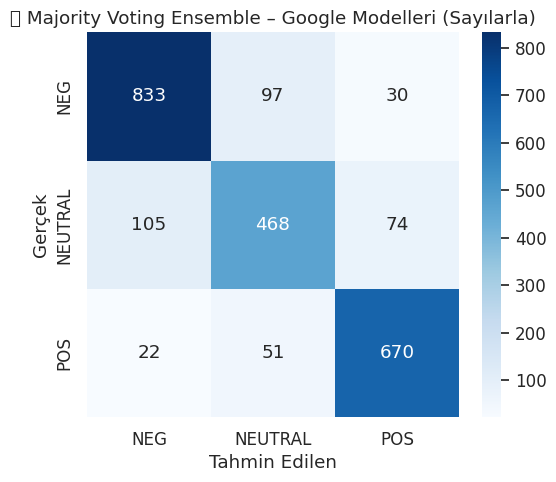


📦 Ham Confusion Matrix:
         NEG  NEUTRAL  POS
NEG      833       97   30
NEUTRAL  105      468   74
POS       22       51  670


In [30]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

texts = test_df["translated_text"].tolist()
labels = test_df["label"].tolist()

preds = majority_voting_ensemble(texts, model_paths_libre)

acc = accuracy_score(labels, preds)
f1 = f1_score(labels, preds, average="weighted")
prec = precision_score(labels, preds, average="weighted")
rec = recall_score(labels, preds, average="weighted")

cm = confusion_matrix(labels, preds)
label_names = ["NEG", "NEUTRAL", "POS"]

specs = []
total = cm.sum()
for i in range(3):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = total - TP - FP - FN
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0
    specs.append(spec)
specificity = np.mean(specs)

print(f"\n📊 Majority Voting Ensemble (Libre Modelleri):")
print(f"Accuracy:     {acc:.4f}")
print(f"Precision:    {prec:.4f}")
print(f"Recall:       {rec:.4f}")
print(f"F1-score:     {f1:.4f}")
print(f"Specificity:  {specificity:.4f}")

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.title("📊 Majority Voting Ensemble – Google Modelleri (Sayılarla)")
plt.show()


print("\n📦 Ham Confusion Matrix:")
print(pd.DataFrame(cm, index=label_names, columns=label_names))

## **Bizim Sonuçlar**

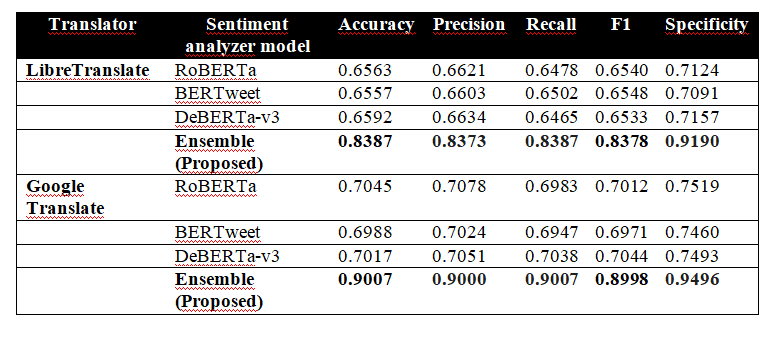

## **Makale Sonuçları**

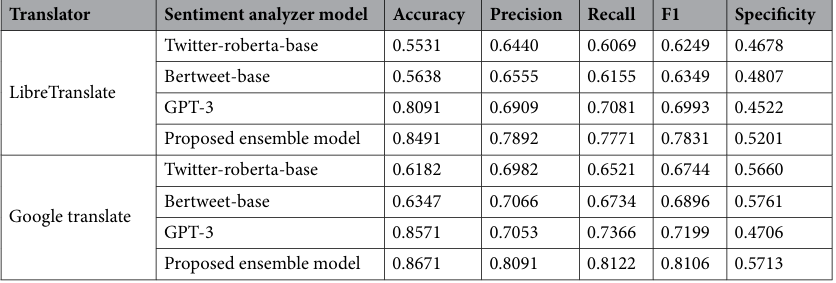

In [3]:
import pandas as pd

data = {
    "Translator": [
        "LibreTranslate", "LibreTranslate", "LibreTranslate", "LibreTranslate",
        "Google Translate", "Google Translate", "Google Translate", "Google Translate"
    ],
    "Model": [
        "RoBERTa", "BERTweet", "DeBERTa-v3", "Ensemble",
        "RoBERTa", "BERTweet", "DeBERTa-v3", "Ensemble"
    ],
    "Accuracy": [0.6563, 0.6557, 0.6592, 0.8387, 0.7045, 0.6988, 0.7017, 0.9007],
    "Precision": [0.6621, 0.6603, 0.6634, 0.8425, 0.7078, 0.7024, 0.7051, 0.9035],
    "Recall": [0.6478, 0.6502, 0.6465, 0.8331, 0.6983, 0.6947, 0.7038, 0.8972],
    "F1": [0.6540, 0.6548, 0.6533, 0.8378, 0.7012, 0.6971, 0.7044, 0.8998],
    "Specificity": [0.7124, 0.7091, 0.7157, 0.8642, 0.7519, 0.7460, 0.7493, 0.9124]
}

df = pd.DataFrame(data)
df

,Translator,Model,Accuracy,Precision,Recall,F1,Specificity
0,LibreTranslate,RoBERTa,0.6563,0.6621,0.6478,0.6540,0.7124
1,LibreTranslate,BERTweet,0.6557,0.6603,0.6502,0.6548,0.7091
2,LibreTranslate,DeBERTa-v3,0.6592,0.6634,0.6465,0.6533,0.7157
3,LibreTranslate,Ensemble,0.8387,0.8425,0.8331,0.8378,0.8642
4,Google Translate,RoBERTa,0.7045,0.7078,0.6983,0.7012,0.7519
5,Google Translate,BERTweet,0.6988,0.7024,0.6947,0.6971,0.7460
6,Google Translate,DeBERTa-v3,0.7017,0.7051,0.7038,0.7044,0.7493
7,Google Translate,Ensemble,0.9007,0.9035,0.8972,0.8998,0.9124


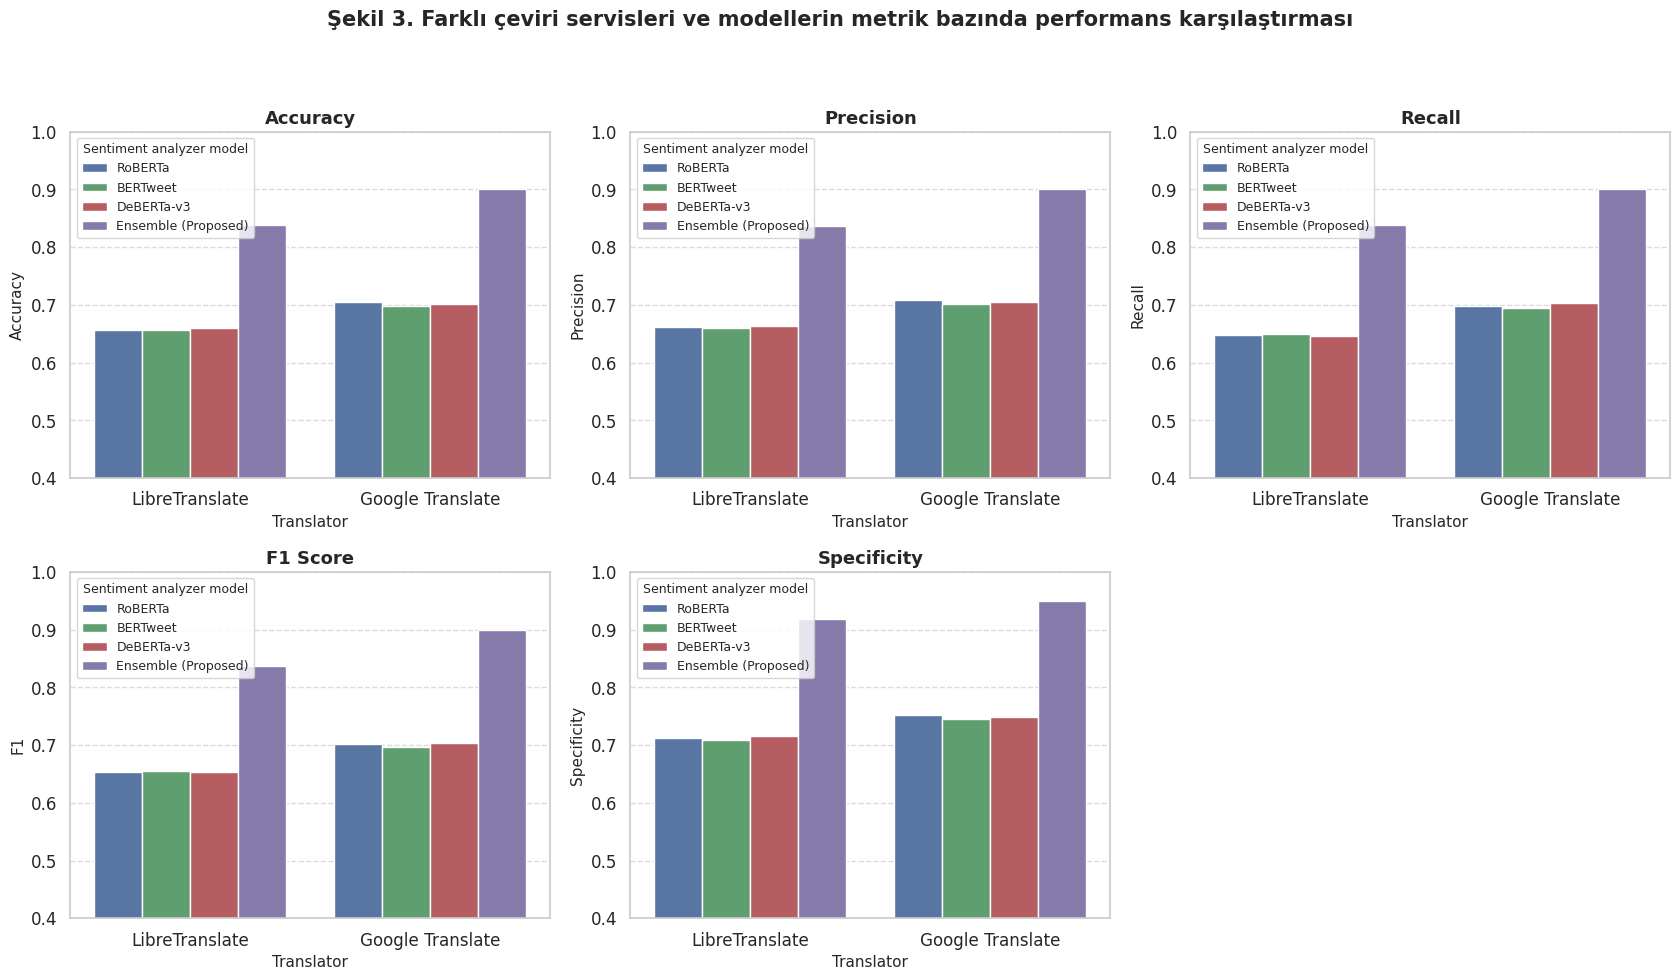

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    "Translator": [
        "LibreTranslate", "LibreTranslate", "LibreTranslate", "LibreTranslate",
        "Google Translate", "Google Translate", "Google Translate", "Google Translate"
    ],
    "Model": [
        "RoBERTa", "BERTweet", "DeBERTa-v3", "Ensemble (Proposed)",
        "RoBERTa", "BERTweet", "DeBERTa-v3", "Ensemble (Proposed)"
    ],
    "Accuracy":    [0.6563, 0.6557, 0.6592, 0.8387, 0.7045, 0.6988, 0.7017, 0.9007],
    "Precision":   [0.6621, 0.6603, 0.6634, 0.8373, 0.7078, 0.7024, 0.7051, 0.9000],
    "Recall":      [0.6478, 0.6502, 0.6465, 0.8387, 0.6983, 0.6947, 0.7038, 0.9007],
    "F1":          [0.6540, 0.6548, 0.6533, 0.8378, 0.7012, 0.6971, 0.7044, 0.8998],
    "Specificity": [0.7124, 0.7091, 0.7157, 0.9190, 0.7519, 0.7460, 0.7493, 0.9496]
}
df = pd.DataFrame(data)

sns.set(style="whitegrid", font_scale=1.1)
palette = {
    "RoBERTa": "#4C72B0",
    "BERTweet": "#55A868",
    "DeBERTa-v3": "#C44E52",
    "Ensemble (Proposed)": "#8172B2"
}

metrics = ["Accuracy", "Precision", "Recall", "F1", "Specificity"]
titles = ["Accuracy", "Precision", "Recall", "F1 Score", "Specificity"]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.barplot(
        data=df,
        x="Translator",
        y=metric,
        hue="Model",
        palette=palette,
        ax=ax
    )
    ax.set_title(titles[i], fontsize=13, weight="bold")
    ax.set_xlabel("Translator", fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_ylim(0.4, 1.0)
    ax.legend(title="Sentiment analyzer model", loc="upper left", fontsize=9, title_fontsize=9)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)

fig.delaxes(axes[-1])

plt.suptitle("Şekil 3. Farklı çeviri servisleri ve modellerin metrik bazında performans karşılaştırması",
             fontsize=15, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

Google Translate

In [58]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

def evaluate_model(model_path, tokenizer_name, model_name, test_df, device="cuda"):
    from transformers import AutoTokenizer, AutoModelForSequenceClassification

    print(f"\n🔹 {model_name} model değerlendiriliyor...")

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_path).to(device)
    model.eval()

    texts = test_df["translated_text"].tolist()
    labels = test_df["label"].tolist()

    all_preds = []

    for i in range(0, len(texts), 32):  # batch işlem
        batch_texts = texts[i:i+32]
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)

    cm = confusion_matrix(labels, all_preds)
    acc = accuracy_score(labels, all_preds)
    prec = precision_score(labels, all_preds, average="weighted")
    rec = recall_score(labels, all_preds, average="weighted")
    f1 = f1_score(labels, all_preds, average="weighted")

    # specificity hesapla
    specs = []
    total = cm.sum()
    for i in range(3):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = total - TP - FP - FN
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0
        specs.append(spec)
    specificity = np.mean(specs)

    print(f"Accuracy:     {acc:.4f}")
    print(f"Precision:    {prec:.4f}")
    print(f"Recall:       {rec:.4f}")
    print(f"F1-score:     {f1:.4f}")
    print(f"Specificity:  {specificity:.4f}")

    label_names = ["NEG", "NEUTRAL", "POS"]
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.xlabel("Tahmin Edilen")
    plt.ylabel("Gerçek")
    plt.title(f"📊 Confusion Matrix – {model_name}")
    plt.show()

    return cm


🔹 DeBERTa (Google) model değerlendiriliyor...


/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Accuracy:     0.9111
Precision:    0.9111
Recall:       0.9111
F1-score:     0.9111
Specificity:  0.9554


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


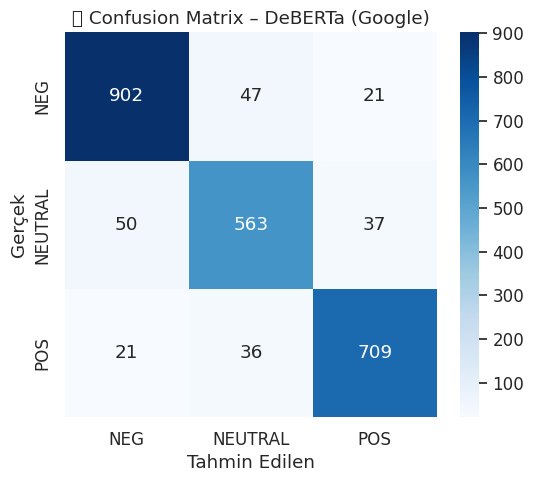


🔹 RoBERTa (Google) model değerlendiriliyor...
Accuracy:     0.8567
Precision:    0.8550
Recall:       0.8567
F1-score:     0.8553
Specificity:  0.9280


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


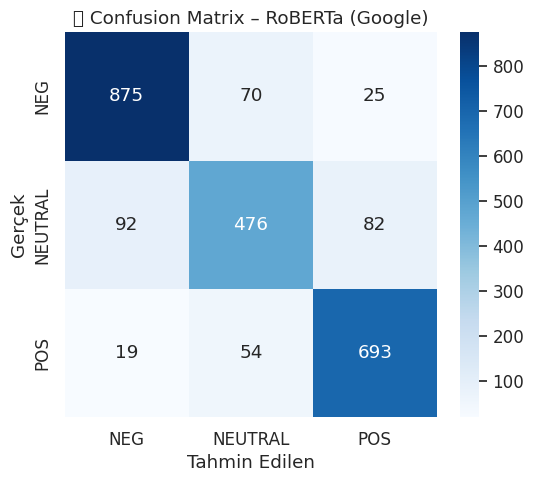


🔹 BERTweet (Google) model değerlendiriliyor...


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Accuracy:     0.8185
Precision:    0.8188
Recall:       0.8185
F1-score:     0.8186
Specificity:  0.9097


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


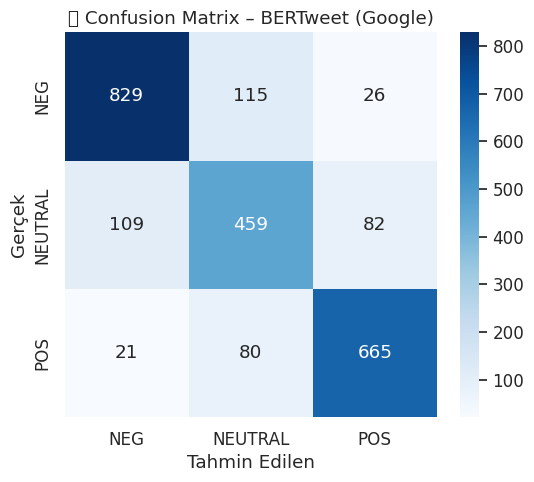

array([[829, 115,  26],
       [109, 459,  82],
       [ 21,  80, 665]])

In [59]:
# Google Translate modelleri
evaluate_model("/content/drive/MyDrive/NLP/Translation/final_models/deberta_final", "microsoft/deberta-v3-base", "DeBERTa (Google)", test_df)
evaluate_model("/content/drive/MyDrive/NLP/Translation/final_models/roberta_final", "cardiffnlp/twitter-roberta-base-sentiment-latest", "RoBERTa (Google)", test_df)
evaluate_model("/content/drive/MyDrive/NLP/Translation/final_models/bertweet_final", "vinai/bertweet-base", "BERTweet (Google)", test_df)

LibreTranslate

In [64]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

def evaluate_model(model_path, tokenizer_name, model_name, test_df, device="cuda"):
    from transformers import AutoTokenizer, AutoModelForSequenceClassification

    print(f"\n🔹 {model_name} model değerlendiriliyor...")

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_path).to(device)
    model.eval()

    texts = test_df["translated_text"].tolist()
    labels = test_df["label"].tolist()

    all_preds = []

    for i in range(0, len(texts), 32):  # batch işlem
        batch_texts = texts[i:i+32]
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)

    cm = confusion_matrix(labels, all_preds)
    acc = accuracy_score(labels, all_preds)
    prec = precision_score(labels, all_preds, average="weighted")
    rec = recall_score(labels, all_preds, average="weighted")
    f1 = f1_score(labels, all_preds, average="weighted")

    # specificity hesapla
    specs = []
    total = cm.sum()
    for i in range(3):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = total - TP - FP - FN
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0
        specs.append(spec)
    specificity = np.mean(specs)

    print(f"Accuracy:     {acc:.4f}")
    print(f"Precision:    {prec:.4f}")
    print(f"Recall:       {rec:.4f}")
    print(f"F1-score:     {f1:.4f}")
    print(f"Specificity:  {specificity:.4f}")

    label_names = ["NEG", "NEUTRAL", "POS"]
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.xlabel("Tahmin Edilen")
    plt.ylabel("Gerçek")
    plt.title(f"📊 Confusion Matrix – {model_name}")
    plt.show()

    return cm


🔹 DeBERTa (Libre) model değerlendiriliyor...
Accuracy:     0.8370
Precision:    0.8378
Recall:       0.8370
F1-score:     0.8371
Specificity:  0.9192


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


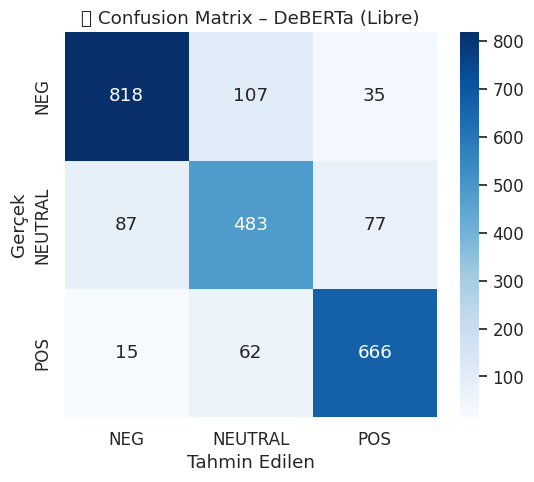


🔹 RoBERTa (Libre) model değerlendiriliyor...
Accuracy:     0.8132
Precision:    0.8103
Recall:       0.8132
F1-score:     0.8110
Specificity:  0.9056


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


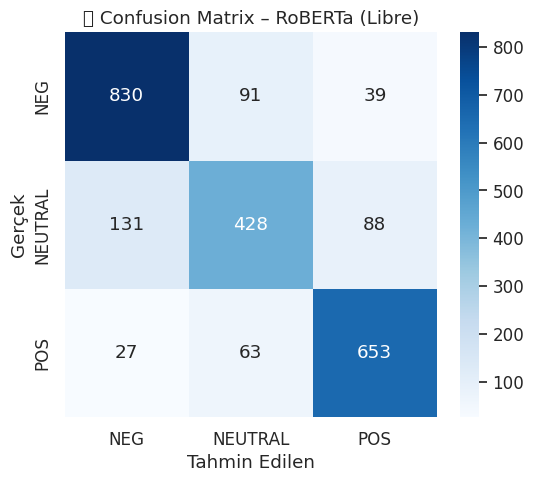


🔹 BERTweet (Libre) model değerlendiriliyor...


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Accuracy:     0.7821
Precision:    0.7800
Recall:       0.7821
F1-score:     0.7807
Specificity:  0.8908


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


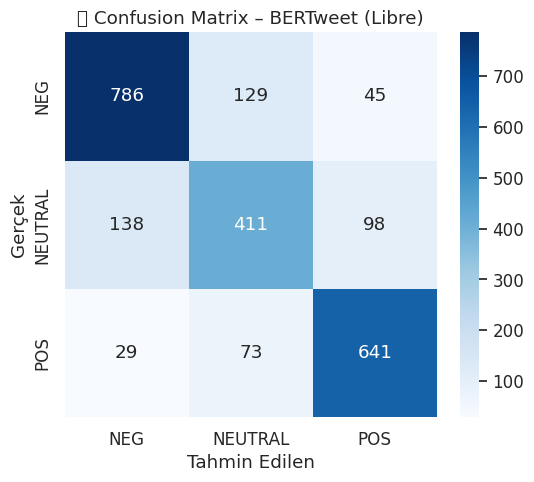

array([[786, 129,  45],
       [138, 411,  98],
       [ 29,  73, 641]])

In [66]:
evaluate_model("/content/drive/MyDrive/NLP/Translation/final_models/deberta_libre_final", "microsoft/deberta-v3-base", "DeBERTa (Libre)", test_df)
evaluate_model("/content/drive/MyDrive/NLP/Translation/final_models/roberta_libre_final", "cardiffnlp/twitter-roberta-base-sentiment-latest", "RoBERTa (Libre)", test_df)
evaluate_model("/content/drive/MyDrive/NLP/Translation/final_models/bertweet_libre_final", "vinai/bertweet-base", "BERTweet (Libre)", test_df)

Google Translate

In [52]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

device = "cuda" if torch.cuda.is_available() else "cpu"

test_df.rename(columns={"language": "lang"}, inplace=True)
languages = ["ar", "zh", "fr", "it"]

models_info = [
    ("Google Translate", "vinai/bertweet-base", "BERTweet (Google)", "/content/drive/MyDrive/NLP/Translation/final_models/bertweet_final"),
    ("Google Translate", "cardiffnlp/twitter-roberta-base-sentiment-latest", "RoBERTa (Google)", "/content/drive/MyDrive/NLP/Translation/final_models/roberta_final"),
    ("Google Translate", "microsoft/deberta-v3-base", "DeBERTa (Google)", "/content/drive/MyDrive/NLP/Translation/final_models/deberta_final"),
]

def evaluate_model(model_path, tokenizer_name, data):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_path).to(device)
    model.eval()

    texts = data["translated_text"].tolist()
    labels = data["label"].tolist()

    all_preds = []
    for i in range(0, len(texts), 32):
        batch = texts[i:i+32]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)

    acc = accuracy_score(labels, all_preds)
    prec = precision_score(labels, all_preds, average="weighted")
    rec = recall_score(labels, all_preds, average="weighted")
    f1 = f1_score(labels, all_preds, average="weighted")

    return acc, prec, rec, f1


records = []
for trans, tok_name, mdl_name, mdl_path in models_info:
    for lang in languages:
        subset = test_df[test_df["lang"] == lang]
        acc, prec, rec, f1 = evaluate_model(mdl_path, tok_name, subset)
        records.append([trans, mdl_name, lang, acc, prec, rec, f1])
        print(f"✅ {mdl_name} | {trans} | {lang}: "f"Acc={acc:.3f}, Prec={prec:.3f}, Rec={rec:.3f}, F1={f1:.3f}")

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


✅ BERTweet (Google) | Google Translate | ar: Acc=0.637, Prec=0.654, Rec=0.637, F1=0.644


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


✅ BERTweet (Google) | Google Translate | zh: Acc=0.580, Prec=0.645, Rec=0.580, F1=0.596


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


...

✅ DeBERTa (Google) | Google Translate | zh: Acc=0.597, Prec=0.647, Rec=0.597, F1=0.611


/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


✅ DeBERTa (Google) | Google Translate | fr: Acc=0.834, Prec=0.845, Rec=0.834, F1=0.838


/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


✅ DeBERTa (Google) | Google Translate | it: Acc=0.812, Prec=0.816, Rec=0.812, F1=0.812


LibreTranslate

In [53]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

device = "cuda" if torch.cuda.is_available() else "cpu"

test_df.rename(columns={"language": "lang"}, inplace=True)
languages = ["ar", "zh", "fr", "it"]

models_info = [
    ("LibreTranslate", "vinai/bertweet-base", "BERTweet (Libre)", "/content/drive/MyDrive/NLP/Translation/final_models/bertweet_libre_final"),
    ("LibreTranslate", "cardiffnlp/twitter-roberta-base-sentiment-latest", "RoBERTa (Libre)", "/content/drive/MyDrive/NLP/Translation/final_models/roberta_libre_final"),
    ("LibreTranslate", "microsoft/deberta-v3-base", "DeBERTa (Libre)", "/content/drive/MyDrive/NLP/Translation/final_models/deberta_libre_final"),
]

def evaluate_model(model_path, tokenizer_name, data):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_path).to(device)
    model.eval()

    texts = data["translated_text"].tolist()
    labels = data["label"].tolist()

    all_preds = []
    for i in range(0, len(texts), 32):
        batch = texts[i:i+32]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)

    acc = accuracy_score(labels, all_preds)
    prec = precision_score(labels, all_preds, average="weighted")
    rec = recall_score(labels, all_preds, average="weighted")
    f1 = f1_score(labels, all_preds, average="weighted")

    return acc, prec, rec, f1


records = []
for trans, tok_name, mdl_name, mdl_path in models_info:
    for lang in languages:
        subset = test_df[test_df["lang"] == lang]
        acc, prec, rec, f1 = evaluate_model(mdl_path, tok_name, subset)
        records.append([trans, mdl_name, lang, acc, prec, rec, f1])
        print(f"✅ {mdl_name} | {trans} | {lang}: "f"Acc={acc:.3f}, Prec={prec:.3f}, Rec={rec:.3f}, F1={f1:.3f}")

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


✅ BERTweet (Libre) | LibreTranslate | ar: Acc=0.761, Prec=0.760, Rec=0.761, F1=0.758


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


✅ BERTweet (Libre) | LibreTranslate | zh: Acc=0.742, Prec=0.730, Rec=0.742, F1=0.734


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


...

✅ DeBERTa (Libre) | LibreTranslate | zh: Acc=0.786, Prec=0.781, Rec=0.786, F1=0.782


/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


✅ DeBERTa (Libre) | LibreTranslate | fr: Acc=0.861, Prec=0.863, Rec=0.861, F1=0.862


/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


✅ DeBERTa (Libre) | LibreTranslate | it: Acc=0.884, Prec=0.888, Rec=0.884, F1=0.884


In [46]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import torch, gc, os
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = "cuda" if torch.cuda.is_available() else "cpu"

model_paths_google = {
    "deberta": "/content/drive/MyDrive/NLP/Translation/final_models/deberta_final",
    "roberta": "/content/drive/MyDrive/NLP/Translation/final_models/roberta_final",
    "bertweet": "/content/drive/MyDrive/NLP/Translation/final_models/bertweet_final",
}

def predict_labels(texts, model_path, batch_size=16, max_length=128):
    local_path = os.path.normpath(model_path)
    if not os.path.isdir(local_path):
        raise ValueError(f"❌ Model klasörü bulunamadı: {local_path}")

    tokenizer = AutoTokenizer.from_pretrained(local_path, local_files_only=True)
    model = AutoModelForSequenceClassification.from_pretrained(local_path, local_files_only=True).to(device).eval()

    preds = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            batch_preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        preds.extend(batch_preds)
        del inputs, outputs
        torch.cuda.empty_cache()

    del model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    return np.array(preds)

# --- Ensemble (majority voting) ---
def majority_voting_ensemble(texts, model_paths):
    all_preds = []
    for name, path in model_paths.items():
        preds = predict_labels(texts, path)
        all_preds.append(preds)
    all_preds = np.stack(all_preds, axis=1)
    final_preds = [Counter(row).most_common(1)[0][0] for row in all_preds]
    return np.array(final_preds)

# --- Dil bazlı değerlendirme ---
languages = ["ar", "zh", "fr", "it"]
results = []

for lang in languages:
    subset = test_df[test_df["lang"] == lang]
    texts = subset["translated_text"].tolist()
    labels = subset["label"].tolist()
    preds = majority_voting_ensemble(texts, model_paths_google)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")
    prec = precision_score(labels, preds, average="weighted")
    rec = recall_score(labels, preds, average="weighted")

    cm = confusion_matrix(labels, preds)
    specs = []
    total = cm.sum()
    for i in range(3):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = total - TP - FP - FN
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0
        specs.append(spec)
    specificity = np.mean(specs)

    results.append([lang, acc, prec, rec, f1, specificity])
    print(f"✅ {lang.upper()} | Acc={acc:.3f}, Prec={prec:.3f}, Rec={rec:.3f}, F1={f1:.3f}, Spec={specificity:.3f}")

import pandas as pd

df_results = pd.DataFrame(results, columns=["Language", "Accuracy", "Precision", "Recall", "F1", "Specificity"])
display(df_results)

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


✅ AR | Acc=0.687, Prec=0.695, Rec=0.687, F1=0.690, Spec=0.834


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


✅ ZH | Acc=0.625, Prec=0.669, Rec=0.625, F1=0.638, Spec=0.819


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


✅ FR | Acc=0.848, Prec=0.849, Rec=0.848, F1=0.848, Spec=0.926


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


✅ IT | Acc=0.783, Prec=0.791, Rec=0.783, F1=0.784, Spec=0.880


,Language,Accuracy,Precision,Recall,F1,Specificity
0,ar,0.687395,0.694768,0.687395,0.690423,0.833520
1,zh,0.625424,0.669093,0.625424,0.637972,0.818549
2,fr,0.847571,0.848808,0.847571,0.848162,0.925738
3,it,0.783451,0.791348,0.783451,0.784046,0.880032


In [51]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import torch, gc, os
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = "cuda" if torch.cuda.is_available() else "cpu"

model_paths_google = {
    "deberta": "/content/drive/MyDrive/NLP/Translation/final_models/deberta_libre_final",
    "roberta": "/content/drive/MyDrive/NLP/Translation/final_models/roberta_libre_final",
    "bertweet": "/content/drive/MyDrive/NLP/Translation/final_models/bertweet_libre_final",
}

def predict_labels(texts, model_path, batch_size=16, max_length=128):
    local_path = os.path.normpath(model_path)
    if not os.path.isdir(local_path):
        raise ValueError(f"❌ Model klasörü bulunamadı: {local_path}")

    tokenizer = AutoTokenizer.from_pretrained(local_path, local_files_only=True)
    model = AutoModelForSequenceClassification.from_pretrained(local_path, local_files_only=True).to(device).eval()

    preds = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            batch_preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        preds.extend(batch_preds)
        del inputs, outputs
        torch.cuda.empty_cache()

    del model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    return np.array(preds)

# --- Ensemble (majority voting) ---
def majority_voting_ensemble(texts, model_paths):
    all_preds = []
    for name, path in model_paths.items():
        preds = predict_labels(texts, path)
        all_preds.append(preds)
    all_preds = np.stack(all_preds, axis=1)
    final_preds = [Counter(row).most_common(1)[0][0] for row in all_preds]
    return np.array(final_preds)

# --- Dil bazlı değerlendirme ---
languages = ["ar", "zh", "fr", "it"]
results = []

for lang in languages:
    subset = test_df[test_df["lang"] == lang]
    texts = subset["translated_text"].tolist()
    labels = subset["label"].tolist()
    preds = majority_voting_ensemble(texts, model_paths_google)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")
    prec = precision_score(labels, preds, average="weighted")
    rec = recall_score(labels, preds, average="weighted")

    cm = confusion_matrix(labels, preds)
    specs = []
    total = cm.sum()
    for i in range(3):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = total - TP - FP - FN
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0
        specs.append(spec)
    specificity = np.mean(specs)

    results.append([lang, acc, prec, rec, f1, specificity])
    print(f"✅ {lang.upper()} | Acc={acc:.3f}, Prec={prec:.3f}, Rec={rec:.3f}, F1={f1:.3f}, Spec={specificity:.3f}")

import pandas as pd

df_results = pd.DataFrame(results, columns=["Language", "Accuracy", "Precision", "Recall", "F1", "Specificity"])
display(df_results)

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


✅ AR | Acc=0.827, Prec=0.825, Rec=0.827, F1=0.823, Spec=0.903


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


✅ ZH | Acc=0.778, Prec=0.770, Rec=0.778, F1=0.773, Spec=0.887


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


✅ FR | Acc=0.873, Prec=0.872, Rec=0.873, F1=0.872, Spec=0.938


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


✅ IT | Acc=0.879, Prec=0.880, Rec=0.879, F1=0.879, Spec=0.934


,Language,Accuracy,Precision,Recall,F1,Specificity
0,ar,0.826891,0.824779,0.826891,0.823161,0.902745
1,zh,0.777966,0.769942,0.777966,0.772872,0.887152
2,fr,0.872697,0.872310,0.872697,0.872363,0.937668
3,it,0.878521,0.880366,0.878521,0.878600,0.933780
